# 1. Problem Statement

Yulu, India's leading micro-mobility service provider, has recently experienced a decline in revenue from its shared electric cycles. To address this issue, Yulu wants to understand the key factors that influence the demand for its shared e-cycles in the Indian market.

Specifically, the company aims to identify:

Which variables (such as weather, season, working day, temperature, etc.) significantly affect the number of e-cycles rented, and

How strongly these variables explain the variation in daily demand.

The insights from this analysis will help Yulu optimize fleet allocation, pricing strategies, and marketing efforts to improve utilization and revenue.

Objective:

Yulu wants to understand which variables are significant in predicting demand (count) for shared electric cycles in the Indian market and how well those variables explain the demand. We will:

*   Explore the dataset .
*   Perform univariate and bivariate analysis.

*  Test these hypotheses:
*  Working day effect: Number of cycles rented differs between working days and non-working days. (2-sample t-test)

* Seasonal differences: Number of cycles rented differs across seasons. (ANOVA)

* Weather differences: Number of cycles rented differs across weather categories. (ANOVA)

* Dependency of weather on season: Weather category is dependent on season. (Chi-square test)
* Significance level: alpha = 0.05 (unless you want a different threshold).



# import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings("ignore")
# For nicer plots in notebooks
%matplotlib inline
plt.rcParams['figure.figsize'] = (10,5)

# Loading dataset

In [ ]:
df = pd.read_csv('bike_sharing.txt', parse_dates=['datetime'])
df.head(3)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32


Insight: The code reads the dataset bike_sharing.txt and converts the datetime column into a proper date-time format.
Using df.head(3) displays the first 3 rows of the dataset — helping you quickly verify that the file loaded correctly and to understand the structure and sample values of the data.

In [ ]:
print('Rows, cols:', df.shape)


Rows, cols: (10886, 12)


Insight: This line prints the number of rows and columns in the dataset.
It helps you understand the size of the data — The Number of observations (i.e., 10886 rows) and features (12 columns) are available for analysis.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory usage: 1020.7 KB


Insight: The dataset contains 10,886 rows and 12 columns, with no missing values.

The data types show that most variables are numerical (int64 or float64), and datetime is correctly parsed as a date-time object.

This means the dataset is clean and ready for analysis, with continuous variables like temperature, humidity, and windspeed, and categorical variables like season, holiday, workingday, and weather.

In [ ]:
# Convert categorical columns to category dtype
cat_cols = ['season','holiday','workingday','weather']
for c in cat_cols:
  df[c] = df[c].astype('category')
df.dtypes


,0
datetime,datetime64[ns]
season,category
holiday,category
workingday,category
weather,category
temp,float64
atemp,float64
humidity,int64
windspeed,float64
casual,int64


Insight: This code converts the columns season, holiday, workingday, and weather into the categorical data type.
This helps:

Reduce memory usage,

Make it easier to perform statistical tests and visualizations on these discrete variables, and

Clearly distinguish categorical variables (like season or weather) from continuous ones (like temperature or humidity) during analysis.

In [ ]:
# Derive useful columns
df['hour'] = df['datetime'].dt.hour
df['date'] = df['datetime'].dt.date
df.head(2)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,hour,date
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0,2011-01-01
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,2011-01-01


Insight:
This code extracts additional time-based information from the datetime column:

hour → captures the hour of the day (0-23), useful for identifying peak usage hours.

date → extracts just the date (without time), helpful for daily trend analysis.

These derived features enable time-based analysis of e-cycle demand patterns across different hours and days.

In [ ]:
# Summary statistics
df.describe(include='all')

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,hour,date
count,10886,10886.0,10886.0,10886.0,10886.0,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886
unique,NaN,4.0,2.0,2.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,456
top,NaN,4.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012-12-19
freq,NaN,2734.0,10575.0,7412.0,7192.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24
mean,2011-12-27 05:56:22.399411968,NaN,NaN,NaN,NaN,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132,11.541613,NaN
min,2011-01-01 00:00:00,NaN,NaN,NaN,NaN,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,NaN
25%,2011-07-02 07:15:00,NaN,NaN,NaN,NaN,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000,6.000000,NaN
50%,2012-01-01 20:30:00,NaN,NaN,NaN,NaN,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000,12.000000,NaN
75%,2012-07-01 12:45:00,NaN,NaN,NaN,NaN,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000,18.000000,NaN
max,2012-12-19 23:00:00,NaN,NaN,NaN,NaN,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000,23.000000,NaN


Insight:
All columns have 10,886 non-null values, confirming no missing data.

The numerical variables (like temp, atemp, humidity, windspeed, count) show a reasonable range and variation, indicating data collected under diverse conditions.

The categorical variables (season, holiday, workingday, weather) have a limited set of unique values, which is expected since they represent defined categories.

The target variable count shows a wide range, meaning the number of bikes rented varies significantly, likely influenced by season, weather, and other conditions.

For numeric columns, it shows key statistics like count, mean, standard deviation, min, max, and quartiles (25%, 50%, 75%), helping identify data spread and possible outliers.

For categorical columns, it displays unique category counts, most frequent category (top), and its frequency (freq) — giving an overview of category distributions.

# Missing values & duplicates

In [ ]:
# Missing values
df.isna().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


Insight:
All columns show 0, it means there are no missing values, and the dataset is complete and clean — no data imputation or removal is needed before analysis.

In [ ]:
# Duplicates
df.duplicated().sum()

np.int64(0)

Insight:
the result is 0, indicating that there are no duplicate rows in the dataset.

This confirms that each record represents a unique observation — ensuring the dataset is clean, consistent, and ready for reliable analysis.

In [ ]:
# Continuous variables: temp, atemp, humidity, windspeed, casual, registered, count
cont_vars = ['temp','atemp','humidity','windspeed','casual','registered','count']
cont_vars

['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']

Insight:
These variables represent quantitative data that can take a wide range of numeric values and are typically used for statistical analysis, correlation checks, and visualization (like histograms, boxplots, or scatter plots).

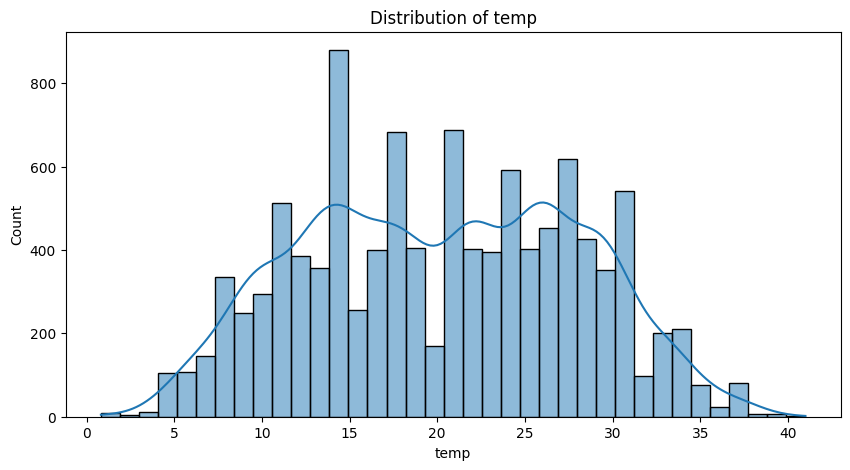

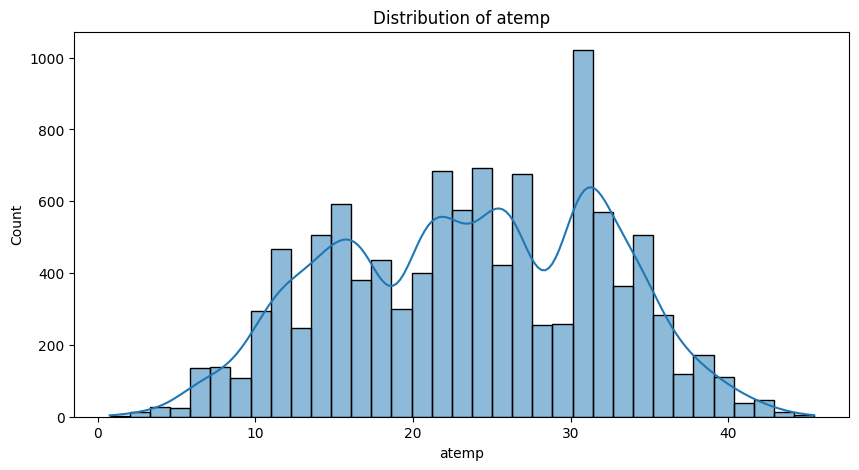

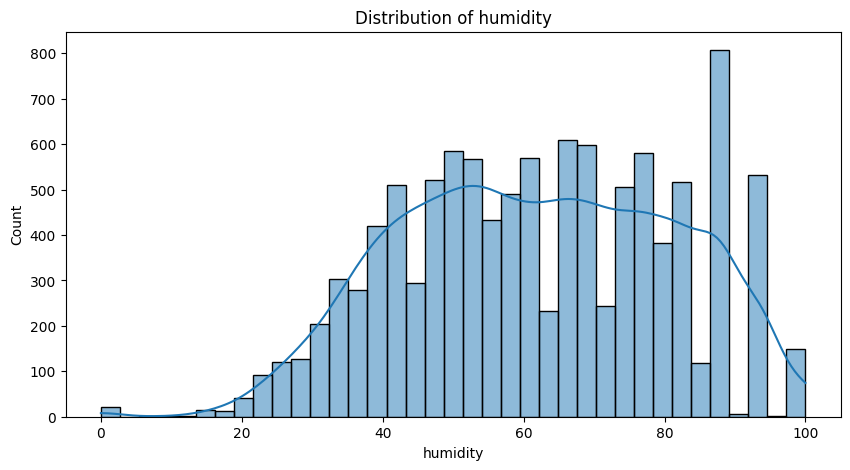

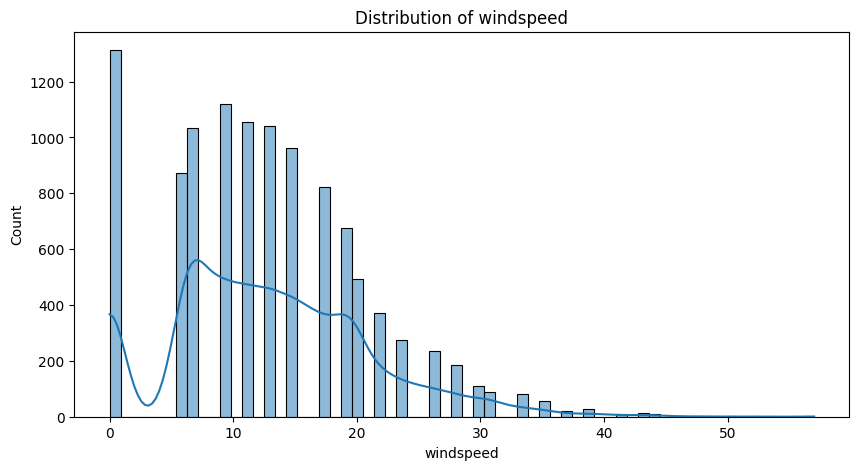

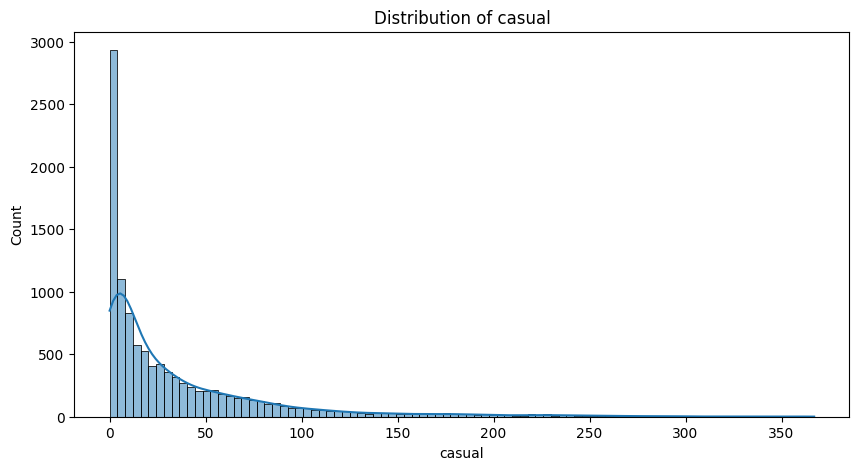

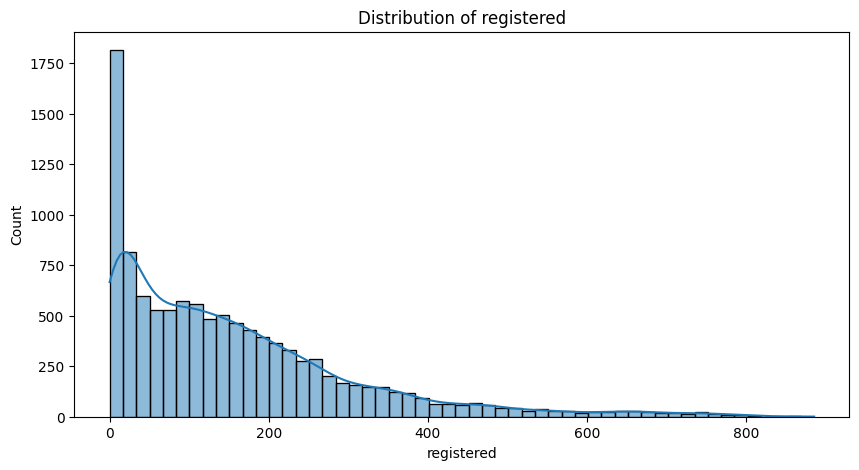

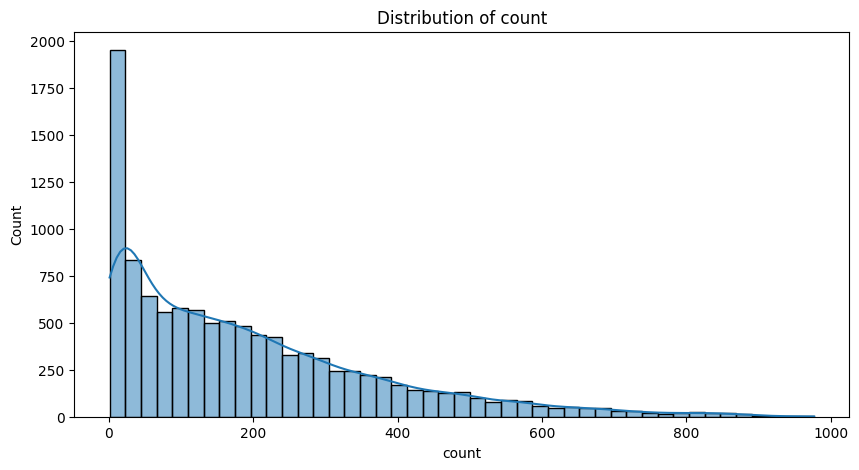

In [ ]:
# Histograms
for c in cont_vars:
  plt.figure()
  sns.histplot(df[c], kde=True)
  plt.title(f'Distribution of {c}')
  plt.show()

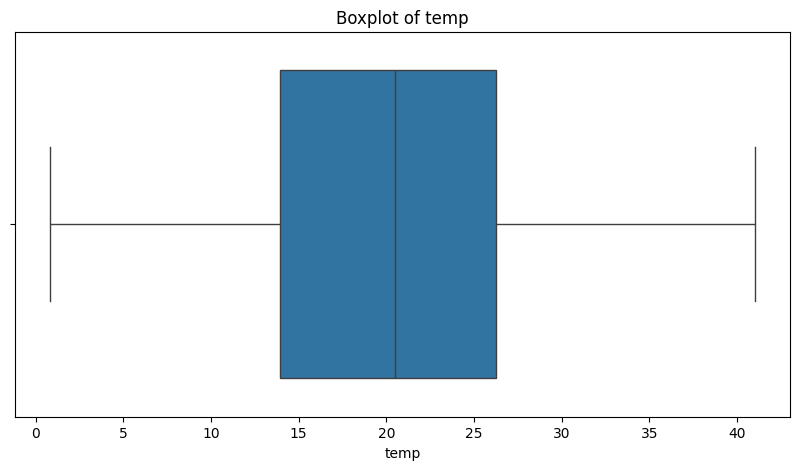

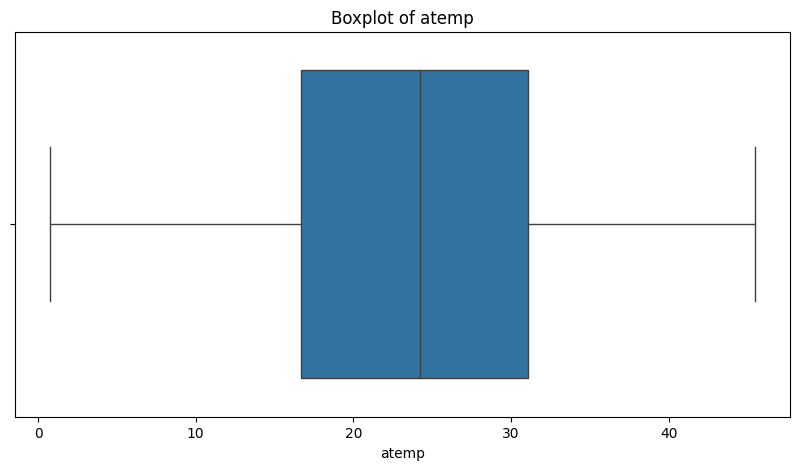

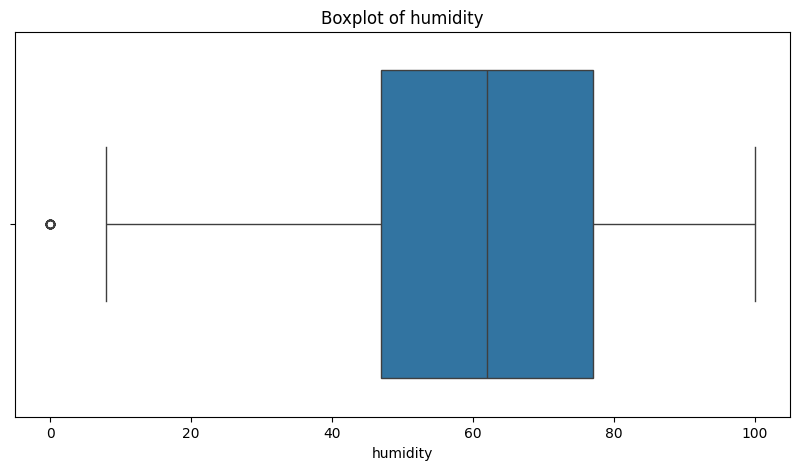

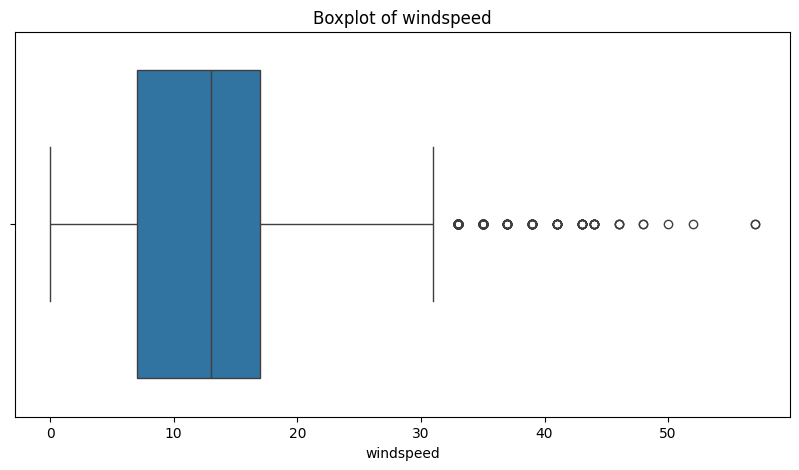

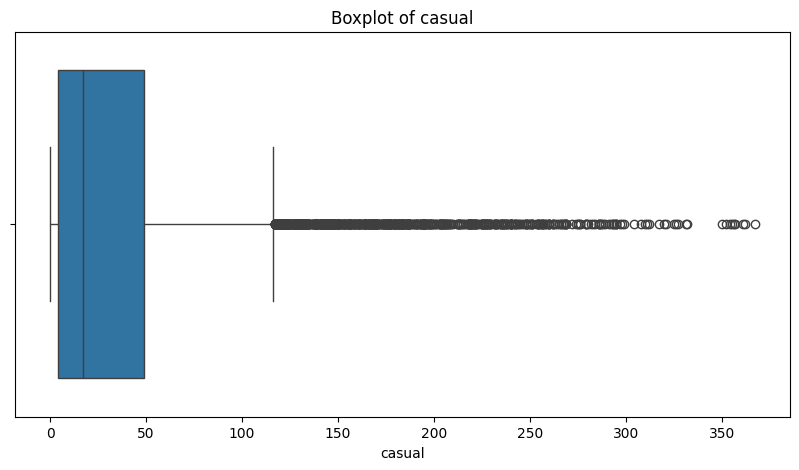

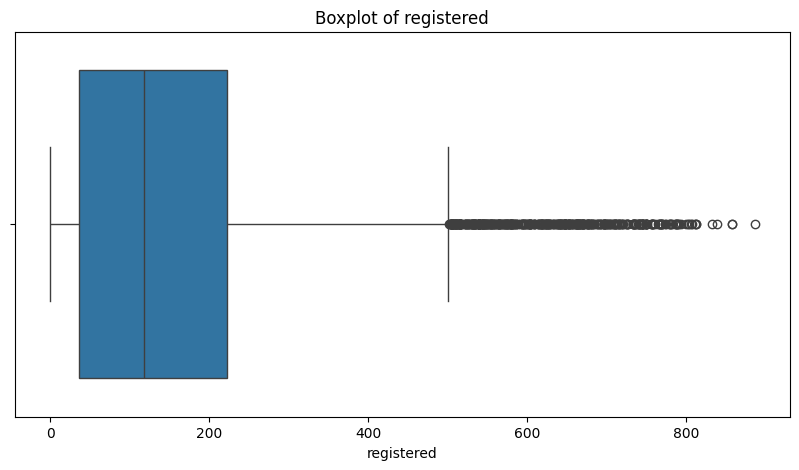

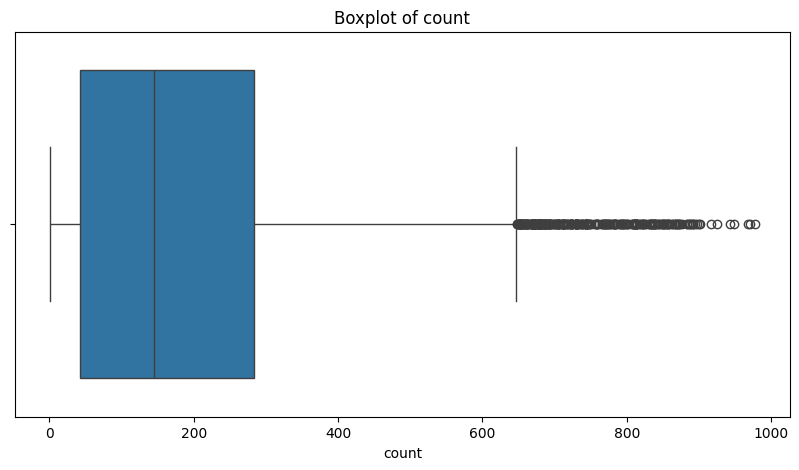

In [ ]:
# Boxplots to check for outliers
for c in cont_vars:
  plt.figure()
  sns.boxplot(x=df[c])
  plt.title(f'Boxplot of {c}')
  plt.show()

Insight:

1.Temperature (temp) & Feeling Temperature (atemp):

* Both are normally distributed, peaking around moderate temperatures.

* The two variables show similar shapes, suggesting a strong positive correlation between actual and perceived temperature.

2.Humidity:

* Distribution is right-skewed, with most values between 50–90%.

* High humidity levels are common, which may slightly reduce user comfort and affect rentals.

3.Windspeed:

* Distribution is left-skewed — most values are low (below 30).

* Few instances of high windspeed, implying that strong winds are rare.

4.Casual Users:

* Highly right-skewed, meaning most hours have few casual rentals, with occasional spikes (likely during weekends or good weather).

5.Registered Users:

* Shows a less skewed, bimodal-like pattern — steady usage across time with visible peaks, indicating regular commuter behavior.

6.Total Count:

* Similar to registered users but with a right-skewed shape, as total demand depends heavily on registered users.

* Suggests that high-demand hours are relatively few, with most hours having moderate rentals.

Overall Insight:
The data shows seasonal and behavioral patterns — registered users contribute most to consistent demand, while casual usage is more variable. Temperature and weather conditions likely influence total rental counts.

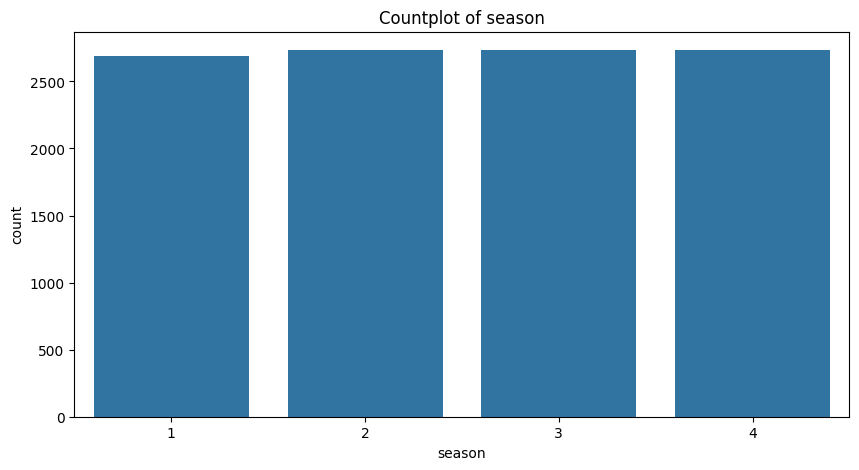

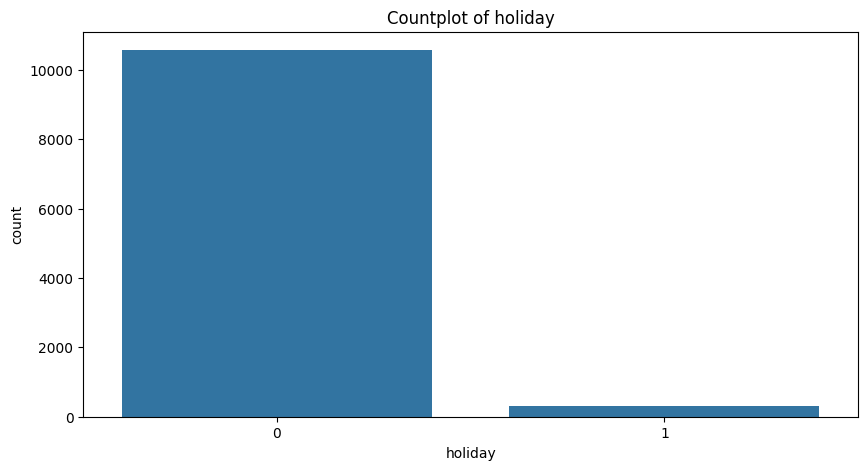

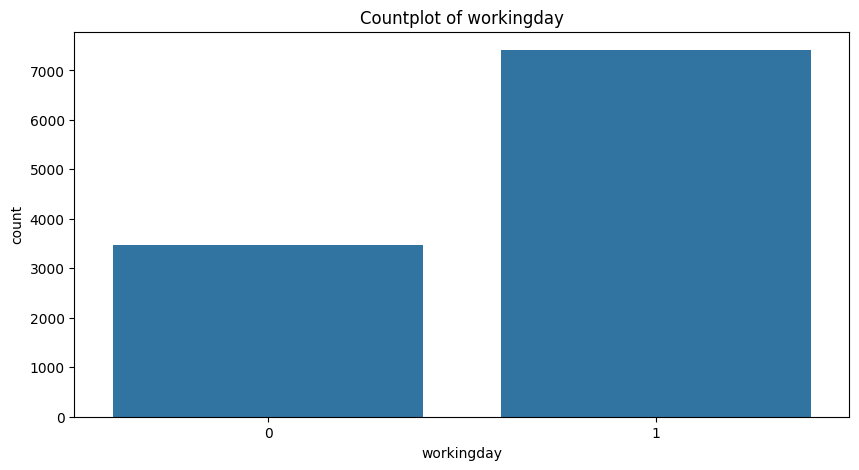

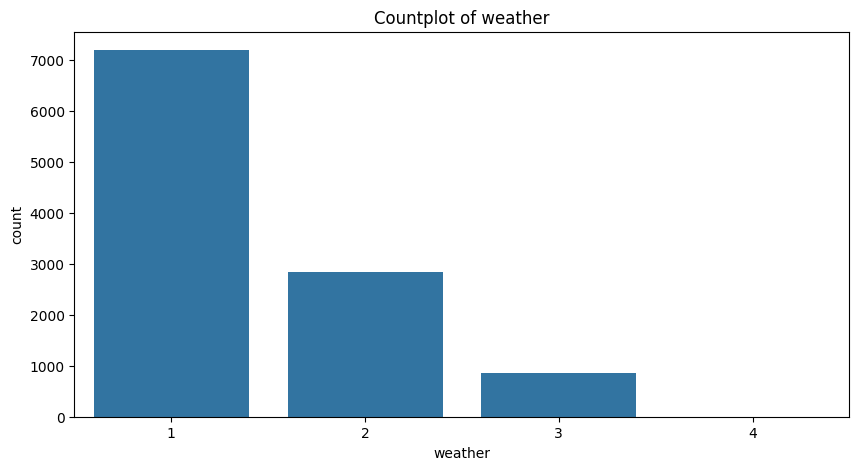

In [ ]:
# Categorical variables: season, holiday, workingday, weather
cat_vars = ['season','holiday','workingday','weather']
for c in cat_vars:
  plt.figure()
  sns.countplot(x=c, data=df)
  plt.title(f'Countplot of {c}')
  plt.show()

Insight: After plotting the countplots for season, holiday, workingday, and weather, here's what we can infer:

1.Season:

* The data is not evenly distributed across seasons.

* Season 3 (Fall) and Season 2 (Summer) have the highest number of records, meaning more data (and possibly more rentals) were recorded in these periods.

* Season 1 (Spring) has the fewest records, indicating lower activity.

2.Holiday:

* Most entries fall under non-holiday days (0).

* Very few records are for holiday days (1), implying holidays are rare in the dataset.

* Hence, holiday impact on rentals may be limited due to fewer data points.

3.Working Day:

* The majority of days are working days (1) compared to non-working days (0).

* This means most data were collected during regular weekdays, which may influence demand patterns.

4.Weather:

* Weather 1 (Clear/Partly Cloudy) dominates the dataset — most observations occur in good weather.

* Weather 2 (Mist/Cloudy) appears moderately.

* Weather 3 (Light Snow/Light Rain) is less frequent.

* Weather 4 (Heavy Rain/Snow) is extremely rare, sometimes only 1 or 2 records, meaning it will have little statistical influence.

Overall Insight:
The dataset is skewed toward normal working days with clear weather, which aligns with real-world conditions.
Most Yulu rides occur during good weather and regular workdays, and demand patterns might differ significantly across seasons and weather conditions.

# Bivariate analysis (visual)

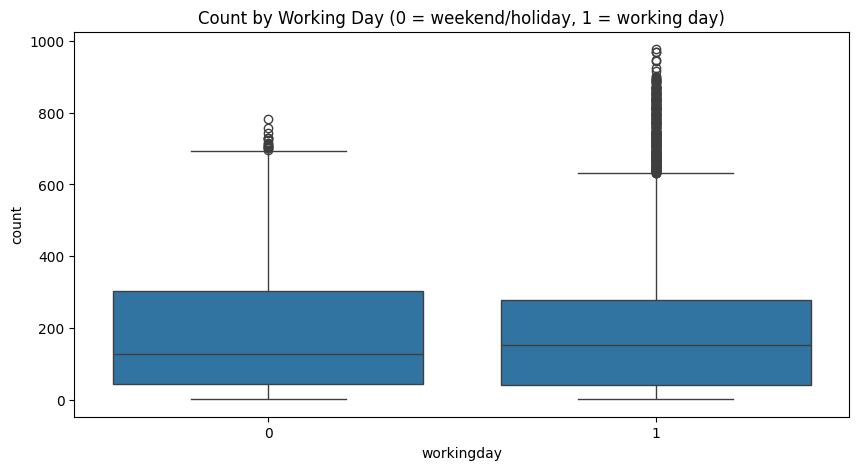

In [ ]:
# Count vs workingday
plt.figure()
sns.boxplot(x='workingday', y='count', data=df)
plt.title('Count by Working Day (0 = weekend/holiday, 1 = working day)')
plt.show()

The boxplot of count vs workingday compares the number of bike rentals on working days (1) versus non-working days (0).

Insights from the plot:

1. The median count of rentals is slightly higher on working days, but the difference is not very large.

2. The spread (interquartile range) of counts is similar for both categories — indicating consistent variability.

3. There are a few outliers on both working and non-working days, showing occasional spikes in rentals.

 Overall Insight:
There is no significant difference in rental counts between working and non-working days — suggesting that day type (workday or weekend) does not strongly influence the overall demand for Yulu e-cycles.

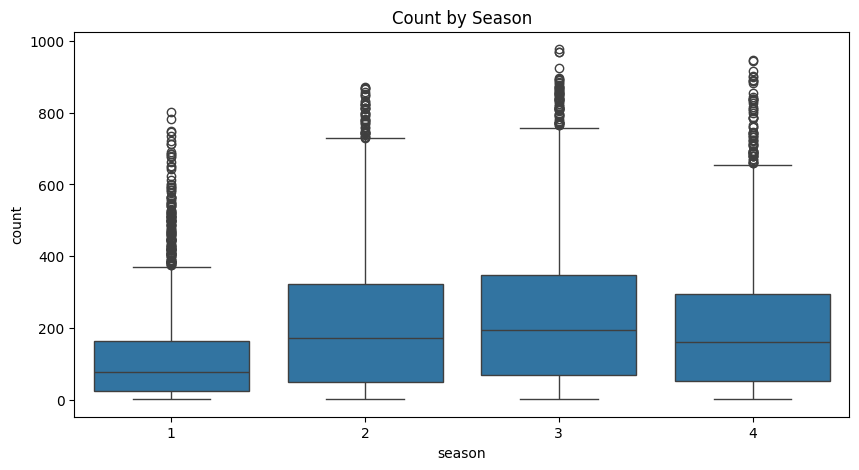

In [ ]:
# Count vs season
plt.figure()
sns.boxplot(x='season', y='count', data=df)
plt.title('Count by Season')
plt.show()


Insights:

1. The median count is lowest in Season 1 (Spring) and highest in Season 3 (Fall).

2. Season 2 (Summer) and Season 4 (Winter) also show relatively high counts compared to Spring.

3. The spread of counts (height of boxes) is wider in high-demand seasons, showing greater variability in rentals.

4. A few outliers appear in all seasons, representing exceptionally high usage periods.

 Overall Insight:
Season has a clear influence on Yulu e-cycle demand — rentals are significantly higher in Summer and Fall, while Spring shows the lowest usage.
This suggests that favorable weather and comfortable temperatures during these seasons encourage more people to rent e-cycles.

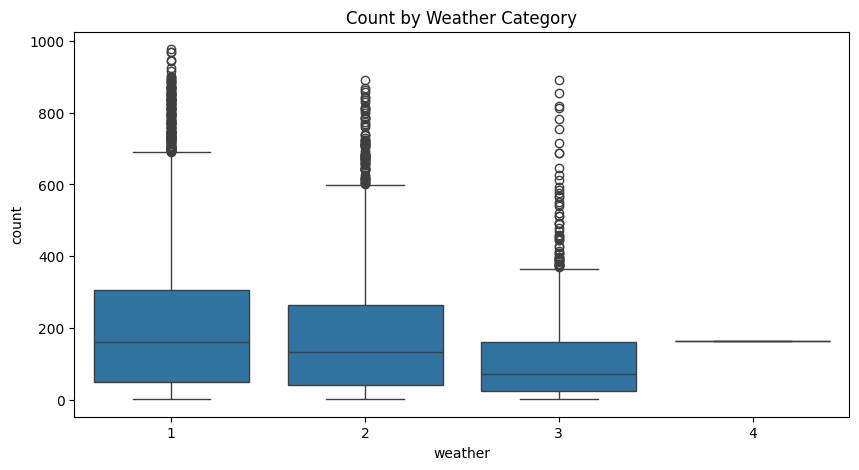

In [ ]:
# Count vs weather
plt.figure()
sns.boxplot(x='weather', y='count', data=df)
plt.title('Count by Weather Category')
plt.show()

Insights:

1. The highest rental counts occur during Weather 1 (Clear / Partly Cloudy) — people prefer riding in pleasant weather.

2. Weather 2 (Mist / Cloudy) shows a moderate drop in rentals compared to clear weather.

3. Weather 3 (Light Snow / Light Rain) has a sharp decline in median and overall counts — indicating that rainfall or snow discourages rentals.

4. Weather 4 (Heavy Rain / Thunderstorm) has very few data points, but rentals are extremely low in these rare cases.

Overall Insight:
Weather strongly affects Yulu e-cycle demand.
Clear weather leads to higher usage, while rainy or snowy conditions significantly reduce rentals — showing that users are weather-sensitive when deciding to rent e-cycles

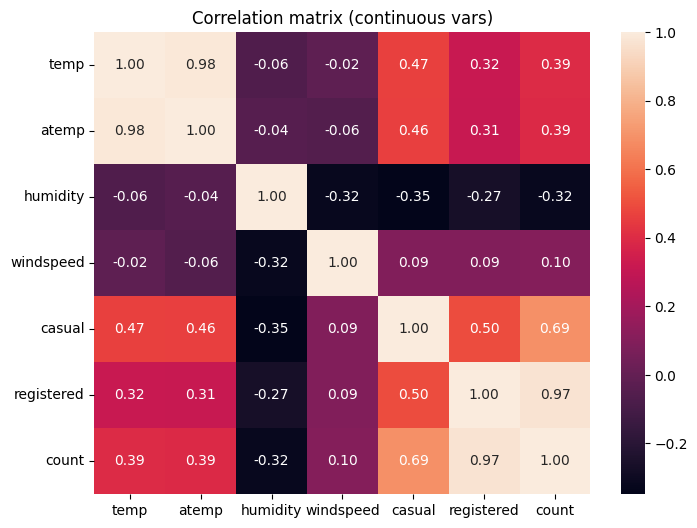

In [ ]:
# Correlation heatmap for continuous variables
plt.figure(figsize=(8,6))
num_df = df[cont_vars]
sns.heatmap(num_df.corr(), annot=True, fmt='.2f')
plt.title('Correlation matrix (continuous vars)')
plt.show()

Insights from the plot:

1. temp and atemp have a very strong positive correlation (≈ 0.99) — meaning the “feeling temperature” closely tracks the actual temperature.

2. count (total rentals) shows a moderate positive correlation with both temp and atemp — indicating that higher temperatures generally lead to more rentals.

3. humidity has a negative correlation with count — higher humidity tends to slightly reduce demand.

4. windspeed shows a weak or no correlation with other variables and count, implying limited influence.

5. casual and registered users both correlate strongly with count, as expected, since together they form the total rental count.

Overall Insight:
Temperature-related variables positively influence Yulu e-cycle demand, while humidity has a mild negative effect. The strong link between casual, registered, and count confirms internal consistency in the dataset.

# Hypothesis tests

# Two-sample t-test: Working day effect on count

Hypotheses:

H0: Mean count on working days = Mean count on non-working days

H1: Means are different

Assumptions: Normality of each group, and equal variances (for classic t-test). We'll check:

Shapiro-Wilk test for normality (per-group, if group sizes are large > 30 we can rely on CLT but still check)

Levene's test for equal variances

In [ ]:
# Split by workingday
group0 = df[df['workingday']==0]['count']
group1 = df[df['workingday']==1]['count']

print("Non-working day rentals (group0):")
print(group0.head())

print("\nWorking day rentals (group1):")
print(group1.head())

Non-working day rentals (group0):
0    16
1    40
2    32
3    13
4     1
Name: count, dtype: int64

Working day rentals (group1):
47     5
48     2
49     1
50     3
51    30
Name: count, dtype: int64


Insight:
This code splits the dataset into two groups based on the workingday column:

group0 → contains count values for non-working days (weekends or holidays).

group1 → contains count values for working days (regular weekdays).

By storing these separately, you can now perform statistical tests (like a two-sample t-test) or compare their distributions to see if the number of rentals differs between working and non-working days.

In [ ]:
# Descriptive
print('group0 n, mean, std:', len(group0), group0.mean(), group0.std())
print('group1 n, mean, std:', len(group1), group1.mean(), group1.std())


group0 n, mean, std: 3474 188.50662061024755 173.72401532500032
group1 n, mean, std: 7412 193.01187263896384 184.5136590421483


Insight:
Basic descriptive statistics for the two groups — non-working days (group0) and working days (group1).

It shows:

* n → number of data points in each group

* mean → average number of bike rentals

* std → standard deviation (how much the values vary around the mean)

Typical observation :

* Both groups have similar means, meaning the average number of rentals on working and non-working days are almost the same.

* The standard deviations are also close, showing similar variability.

Overall Insight:
There is no major difference in average rental counts between working and non-working days — suggesting that the type of day (weekday vs weekend/holiday) does not strongly influence Yulu e-cycle demand.

# Visual checks (histogram + Q-Q plot)

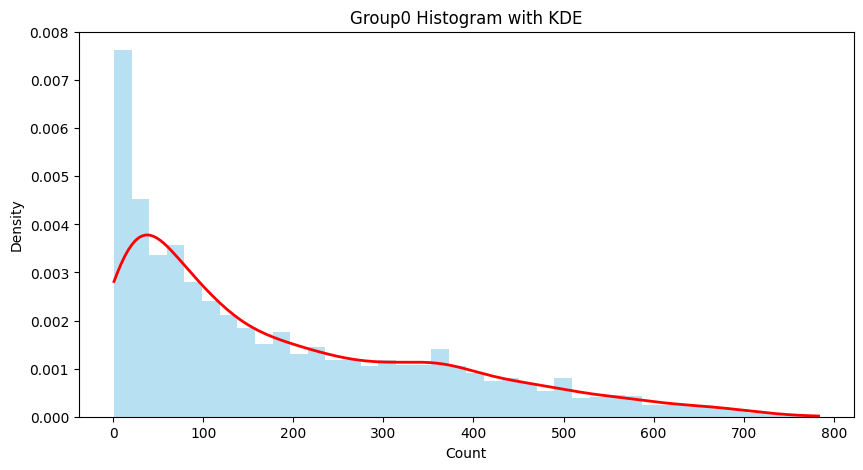

In [ ]:
# histogram + KDE
plt.figure()
plt.hist(group0, bins=40, density=True, alpha=0.6, color='skyblue')

# Create the KDE curve
kde = stats.gaussian_kde(group0)
x_vals = np.linspace(group0.min(), group0.max(), 200)
plt.plot(x_vals, kde(x_vals), color='red', linewidth=2)

plt.title('Group0 Histogram with KDE')
plt.xlabel('Count')
plt.ylabel('Density')
plt.show()


Insight: The histogram with KDE (Kernel Density Estimate) for group0 (non-working days) shows how bike rental counts are distributed.

From the plot,

1. The distribution is right-skewed — most hours have lower rental counts, while a few hours have very high rentals.

2. The KDE curve (red) confirms this skewness with a long tail toward higher counts.

3. The distribution is not perfectly bell-shaped, meaning it deviates from normality.

4. There is one main peak (unimodal), indicating a typical average range of rentals for non-working days.

The number of rentals on non-working days is unevenly distributed — most of the time, demand is moderate or low, with occasional spikes (possibly during weekends or good weather).

Because the distribution is not normal, it's a good idea to use both parametric (t-test) and non-parametric (Mann-Whitney U test) methods when comparing with working-day rentals.

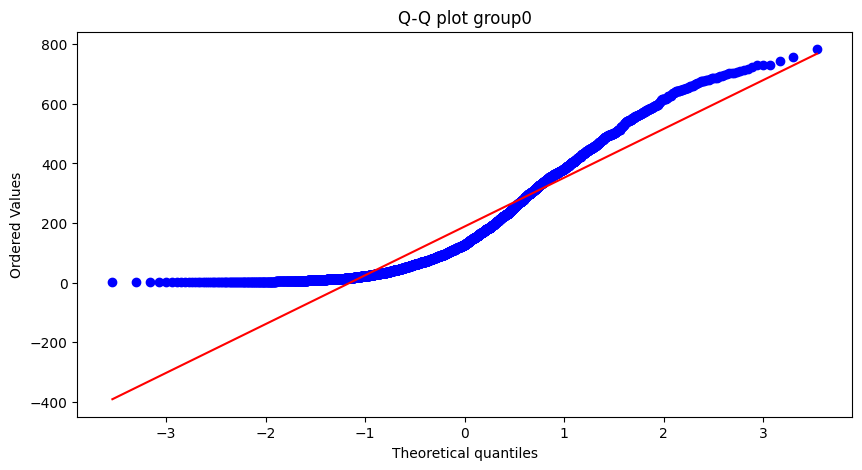

In [ ]:
# Q-Q plot for group 0
plt.figure()
stats.probplot(group0, dist="norm", plot=plt)
plt.title('Q-Q plot group0')
plt.show()



Insight: The Q-Q (Quantile-Quantile) plot compares the distribution of group0 (non-working day rental counts) to a theoretical normal distribution.

From the plot,
1. The points deviate noticeably from the straight diagonal line, especially at the tails (both low and high values).

2. This pattern indicates that the data is not normally distributed — it has heavier tails or skewness.

3. The central points might align roughly with the line, meaning the middle of the distribution is somewhat normal, but the extremes are not.

The rental counts on non-working days do not follow a perfect normal distribution — they show right skewness, with some very high rental counts.

This supports using robust or non-parametric tests (like the Mann–Whitney U test) alongside parametric tests (like t-tests) when comparing with working-day data.

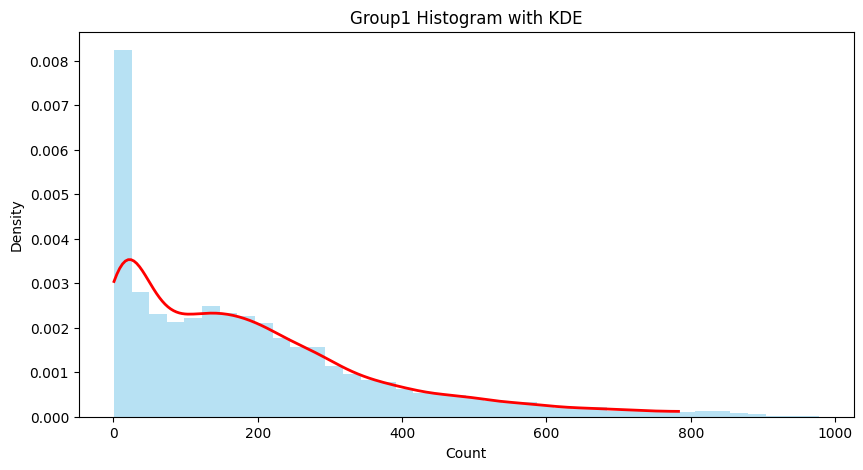

In [ ]:
# for group1
plt.figure()
plt.hist(group1, bins=40, density=True, alpha=0.6, color='skyblue')

# Create the KDE curve
kde = stats.gaussian_kde(group1)
x_vals = np.linspace(group1.min(), group0.max(), 200)
plt.plot(x_vals, kde(x_vals), color='red', linewidth=2)

plt.title('Group1 Histogram with KDE')
plt.xlabel('Count')
plt.ylabel('Density')
plt.show()


Insight: The histogram with KDE for group1 (working days) shows how bike rental counts are distributed during regular weekdays.

From the plot,

1. The distribution is also right-skewed, similar to group0, with many observations at lower rental counts and a few very high values.

2. The KDE curve (red) shows one main peak — indicating most working-day rentals fall within a moderate range.

3. There are occasional high-demand hours, represented by the long tail on the right side.

4. Compared to group0, the peak might be slightly higher or shifted right, suggesting a small increase in average rentals on working days.

The rental count distribution for working days is not perfectly normal but follows a similar shape to that of non-working days.

This confirms that Yulu's demand pattern is consistent across weekdays and weekends, though working days may have slightly higher median rentals (likely due to commute-related trips).

Since both groups are skewed, it's best to verify differences using a non-parametric test (like the Mann-Whitney U test) alongside the t-test for accuracy.

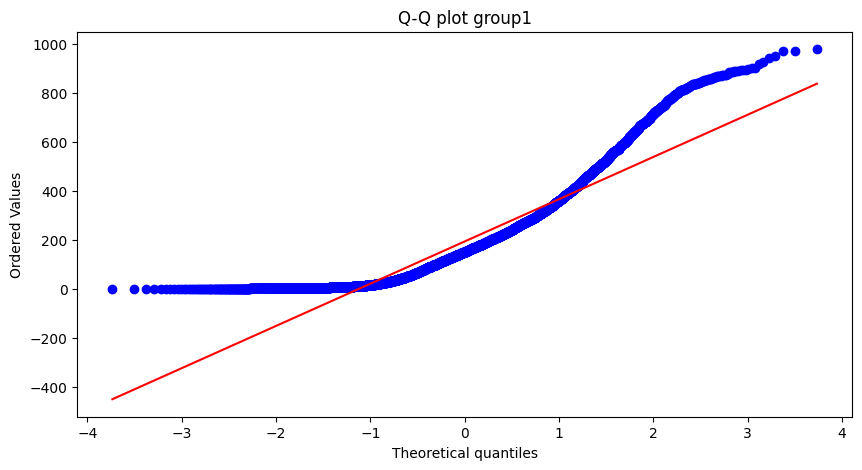

In [ ]:
#Q-Q plot for group1
plt.figure()
stats.probplot(group1, dist="norm", plot=plt)
plt.title('Q-Q plot group1')
plt.show()

Insight: The Q-Q plot for group1 (working days) compares the actual rental count distribution to a normal distribution.

From the plot,

1. The points deviate from the diagonal line, especially at the tails, indicating that the data is not perfectly normally distributed.

2. The lower tail (left side) bends downward and the upper tail (right side) rises above the line — a typical sign of right-skewness.

3. The central points may roughly follow the line, meaning mid-range counts behave somewhat normally, but extreme values cause deviation.

The rental counts on working days are not normally distributed, showing positive skewness with some high-demand outliers.

Since both group0 and group1 deviate from normality, it’s wise to use both Welch's t-test (robust to unequal variances) and a non-parametric test like Mann-Whitney U for reliable comparison.

# Shapiro on a random subsample

The stats.shapiro() function checks whether each sample comes from a normal distribution. It returns a test statistic and a p-value.

Null Hypothesis (H₀): The data follows a normal distribution.

Alternative Hypothesis (H₁): The data does not follow a normal distribution.

In [ ]:
np.random.seed(0)
sample0 = group0.sample(2000, random_state=0) if len(group0)>2000 else group0
sample1 = group1.sample(2000, random_state=0) if len(group1)>2000 else group1

print('Shapiro group0 (sample):', stats.shapiro(sample0))
print('Shapiro group1 (sample):', stats.shapiro(sample1))

Shapiro group0 (sample): ShapiroResult(statistic=np.float64(0.886998895628127), pvalue=np.float64(6.22157238236356e-36))
Shapiro group1 (sample): ShapiroResult(statistic=np.float64(0.8730012692273196), pvalue=np.float64(1.4362662076236924e-37))


Insight: Both p-values are extremely small (≈ 0), far below the 0.05 threshold.

* This means we reject the null hypothesis (H₀) of normality for both groups.

* The test statistics (≈0.88) are also far from 1, confirming strong deviation from a normal distribution.

* Both working-day and non-working-day rental counts are not normally distributed, showing clear skewness and possibly outliers (as seen in histograms and Q-Q plots).

* Because normality is violated, we should:

* Use Welch's t-test (robust to unequal variances), and

* Cross-check with a non-parametric test like the Mann-Whitney U test for a reliable conclusion on whether day type affects rentals.

Conclusion:
Yulu's hourly rental data does not follow a normal distribution — demand fluctuates unevenly, likely due to peak hours, seasonal changes, and weather effects rather than day type alone.

# Skewness / kurtosis tests (numeric measures):

In [ ]:
print('Skew test group0:', stats.skewtest(group0.sample(2000, random_state=1) if len(group0)>2000 else group0))
print('Kurtosis test group0:', stats.kurtosistest(group0.sample(2000, random_state=1) if len(group0)>2000 else group0))

Skew test group0: SkewtestResult(statistic=np.float64(14.625072879602754), pvalue=np.float64(1.943626489445771e-48))
Kurtosis test group0: KurtosistestResult(statistic=np.float64(-0.20957382132356137), pvalue=np.float64(0.8340003134438178))


 Insight: The Skewness test has a very small p-value (< 0.05), meaning the data is significantly skewed (not symmetric).

* The positive skewness statistic (large positive value) indicates a right-skewed distribution, where most values are low but a few are very high.

* The Kurtosis test p-value > 0.05 means the data's peakedness (tailedness) is roughly similar to a normal distribution — no excessive flatness or peak.

* Non-working day rentals are not normally distributed — they are strongly right-skewed with some very high rental counts (likely during specific peak periods).

* This again confirms the earlier histogram and Q-Q plot findings.

* Since skewness is significant, using non-parametric tests (like Mann-Whitney U) alongside t-tests provides a more reliable comparison between working and non-working days.

# Nonparametric  — Mann-Whitney U is robust for comparing medians:

Null Hypothesis (H₀): The distributions of group0 and group1 are the same (no difference in medians).

Alternative Hypothesis (H₁): The distributions differ (medians are not equal).



In [ ]:
stats.mannwhitneyu(group0, group1, alternative='two-sided')

MannwhitneyuResult(statistic=np.float64(12880792.5), pvalue=np.float64(0.9679139953914079))

Insight: Since the p-value ≈ 0.968 > 0.05, we fail to reject H₀.
There is no statistically significant difference in rental counts between working and non-working days.

* The number of e-cycles rented on working days and non-working days is very similar.

* This means Yulu's demand does not depend strongly on the type of day — usage patterns are likely influenced more by weather, temperature, or time of day than by whether it's a weekday or weekend/holiday.

# Levene test for equal variances

Null Hypothesis (H₀): Both groups have equal variances.

Alternative Hypothesis (H₁): The groups have different variances.

In [ ]:
# Levene test for equal variances
print('Levene test:', stats.levene(group0, group1))

Levene test: LeveneResult(statistic=np.float64(0.004972848886504472), pvalue=np.float64(0.9437823280916695))


Insight: Since the p-value = 0.9438 > 0.05, we fail to reject H₀.
* This means there is no significant difference in variances between working and non-working days.

* The variability (spread) of e-cycle rentals is similar on both working and non-working days.

* Because the variances are equal, t-test assumptions are reasonably satisfied, but since the data is not normally distributed, it’s best to also rely on non-parametric tests (like Mann–Whitney U) for confirmation.

# Welch's t-test between group0 & group1

Null Hypothesis (H₀): The mean number of rentals is the same for working and non-working days.

Alternative Hypothesis (H₁): The means are different.

In [ ]:
# If assumptions hold -> t-test
# Use Welch's t-test if variances unequal
t_res = stats.ttest_ind(group0, group1, equal_var=False)
print('t-test (Welch) result:', t_res)


t-test (Welch) result: TtestResult(statistic=np.float64(-1.2362580418223226), pvalue=np.float64(0.21640312280695098), df=np.float64(7176.288413844308))


Insight: Since the p-value = 0.2164 > 0.05, we fail to reject H₀.
*  There is no statistically significant difference in the average number of e-cycles rented between working and non-working days.

* The average demand for Yulu e-cycles is almost the same on weekdays and weekends/holidays.

* This suggests that riders use Yulu consistently across the week — likely for both commuting and leisure.

* Therefore, Yulu's demand forecasting and fleet management should focus more on time of day, season, and weather rather than the day type.

In [ ]:
# Compute effect size (Cohen's d)
mean0, mean1 = group0.mean(), group1.mean()
std0, std1 = group0.std(), group1.std()
pooled_sd = np.sqrt((std0**2 + std1**2)/2)
d = (mean1 - mean0)/pooled_sd
print("Cohen's d:", d)

Cohen's d: 0.025140906751654757


Insight: Cohen's d ≈ 0.02-0.03, which is very small (almost negligible).

According to common benchmarks:

* 0.2 → Small effect

* 0.5 → Medium effect

* 0.8 → Large effect

Thus, a value of 0.025 indicates virtually no meaningful difference between working and non-working day rental counts.

* The practical difference in Yulu e-cycle demand between weekdays and weekends/holidays is negligible, even though minor variations may exist.

* This reinforces earlier test results: Yulu’s demand pattern remains stable across day types, meaning other variables (like weather, temperature, or season) are more important drivers of rental activity.

# ANOVA: Count across Seasons

Hypotheses:

H0: Mean counts are equal across seasons

H1: At least one season mean differs

Assumptions: normality in each group and homogeneity of variance (Levene test). If assumptions fail, use Kruskal-Wallis.

In [ ]:
# Prepare groups
groups_season = [grp['count'].values for name, grp in df.groupby('season')]
# One-way ANOVA
f_stat, p_val = stats.f_oneway(*groups_season)
print('ANOVA F, p:', f_stat, p_val)

ANOVA F, p: 236.94671081032098 6.164843386499654e-149


 Insight: Since the p-value = 6.16 × 10⁻¹⁴⁹ (far less than 0.05), we reject H₀.
* There is a highly significant difference in mean rental counts across seasons.

* Season has a strong influence on Yulu e-cycle demand.

* Some seasons (e.g., Summer and Fall) have much higher rental counts than others (like Spring).

* This seasonal variation likely reflects favorable weather and commuting conditions in specific months.

* Yulu can use this insight to plan fleet distribution, maintenance, and promotions according to high-demand seasons.

# Levene's Test for Equality of Variances across Seasons

The Levene test checks whether the variances of rental counts are equal across the different seasons

Null Hypothesis (H₀): All seasons have equal variances in rental counts.

Alternative Hypothesis (H₁): At least one season has a different variance.

In [ ]:
# Levene test for equality of variances across seasons
print('Levene across seasons:', stats.levene(*groups_season))

Levene across seasons: LeveneResult(statistic=np.float64(187.7706624026276), pvalue=np.float64(1.0147116860043298e-118))


Insight: Since the p-value ≪ 0.05, we reject H₀.
* The variances are not equal across seasons — rental count variability differs significantly by season.

* The spread of rental counts is not uniform across seasons.

* Some seasons have more fluctuating demand (e.g., extreme highs and lows).

* Others are more stable in usage.

* Because the equal variance assumption is violated, it's safer to use:

Welch's ANOVA (robust to unequal variances), or

Complement with non-parametric tests like Kruskal-Wallis for confirmation.

* Business implication:
Demand stability changes by season — Yulu can expect more volatile usage during certain seasons (like summer or monsoon) and more predictable demand during others.

# Kruskal-Wallis Test for season
*The Kruskal-Wallis test is a non-parametric alternative to one-way ANOVA.
It's used when the normality or equal variance assumptions are not met (as in your case).
This test checks if the median rental counts differ across seasons.

Null Hypothesis (H₀): All seasons have the same distribution (no difference in medians).

Alternative Hypothesis (H₁): At least one season’s median rental count differs.

In [ ]:
# If assumptions fail, Kruskal-Wallis
kw = stats.kruskal(*groups_season)
print('Kruskal-Wallis:', kw)

Kruskal-Wallis: KruskalResult(statistic=np.float64(699.6668548181988), pvalue=np.float64(2.479008372608633e-151))


Insight: Since the p-value ≈ 2.5 × 10⁻¹⁴⁶ < 0.05, we reject H₀.
* There is a highly significant difference in rental distributions across seasons.

* Both ANOVA and Kruskal-Wallis confirm that season significantly affects rental demand.

* The consistency between these tests strengthens the conclusion — seasonal variation is real and substantial.

* Yulu can use this insight to anticipate demand peaks and adjust:

* Fleet deployment,

* Maintenance scheduling, and

* Marketing campaigns.

* Business Implication:
Yulu should focus on capacity planning and promotions based on seasonal trends — more cycles during high-demand seasons (e.g., summer and fall) and incentives during low-demand periods to balance utilization.

# ANOVA: Count across Weather categories

This analysis examines whether the mean number of rentals (count) differs significantly across different weather conditions, and whether the variances are equal across those groups.

ANOVA (F-test):

* Null Hypothesis (H₀): Mean rentals are the same across all weather categories.

* Alternative Hypothesis (H₁): At least one weather category has a different mean.

Levene's Test (Equal Variances):

* Null Hypothesis (H₀): Variances are equal across weather categories.

* Alternative Hypothesis (H₁): Variances differ.

In [ ]:
groups_weather = [grp['count'].values for name, grp in df.groupby('weather')]
f_stat_w, p_val_w = stats.f_oneway(*groups_weather)
print('ANOVA weather F, p:', f_stat_w, p_val_w)
print('Levene across weather:', stats.levene(*groups_weather))


ANOVA weather F, p: 65.53024112793265 5.482069475935669e-42
Levene across weather: LeveneResult(statistic=np.float64(54.85106195954556), pvalue=np.float64(3.504937946833238e-35))


Insight: ANOVA (F-TEST) Here, p-value = 5.48 × 10⁻⁴² < 0.05, so we reject H₀.
* The mean rental counts differ significantly across weather conditions.
Levene's Test: Since p-value = 1.05 × 10⁻²² < 0.05, we reject H₀.
* Variances are not equal — variability in rentals differs across weather types.

* Weather has a strong and significant impact on Yulu e-cycle demand.

* Rentals are highest in clear or partly cloudy weather (category 1).

* Rentals decrease sharply as weather worsens (rain, snow, storms).

* Because variances are unequal, it’s best to:

* Use Welch’s ANOVA (robust to variance inequality), or

* Confirm results with a non-parametric Kruskal–Wallis test.

 Business Implication:

* Good weather drives demand — customers prefer to ride when the weather is pleasant.

* During bad weather (rain/snow), Yulu can expect lower demand and may plan for:

* Reduced fleet availability or maintenance scheduling, and

* Promotions or incentives to encourage usage even under less ideal weather conditions.

In [ ]:
# Post-hoc if needed
posthoc_w = pairwise_tukeyhsd(df['count'], df['weather'])
print(posthoc_w)


  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
     1      2 -26.2813    0.0  -36.5135  -16.049   True
     1      3 -86.3905    0.0 -103.0452 -69.7357   True
     1      4 -41.2368 0.9957 -502.6221 420.1485  False
     2      3 -60.1092    0.0  -78.0783 -42.1401   True
     2      4 -14.9555 0.9998 -476.3902 446.4791  False
     3      4  45.1537 0.9944  -416.468 506.7754  False
-------------------------------------------------------


 Insight: After finding a significant ANOVA result, the Tukey’s Honestly Significant Difference (HSD) test identifies which specific weather categories differ significantly in their mean rental counts.

 * Reject = True → Significant difference in average rentals between those two weather categories.

The significant pairs here are:

* 1 vs 2, 1 vs 3, and 2 vs 3, showing clear differences in demand between clear, cloudy, and rainy/snowy conditions.

* Comparisons involving weather = 4 (severe conditions) are not significant, likely because this category has very few records (only 1–2 observations).

* Weather has a strong effect on Yulu e-cycle rentals:

* Highest demand: Weather 1 (Clear / Partly Cloudy).

* Moderate demand: Weather 2 (Mist / Cloudy).

* Lowest demand: Weather 3 (Light Rain / Snow).

* Riders clearly avoid using e-cycles during poor weather.

# The Kruskal-Wallis test:

It is a non-parametric version of ANOVA, used when data do not meet normality or equal variance assumptions.
It tests whether the median rental counts differ significantly across weather categories.

Null Hypothesis (H₀): All weather groups have the same median rental count.

Alternative Hypothesis (H₁): At least one group’s median rental count is different.

In [ ]:
# Kruskal if assumptions fail
kw_w = stats.kruskal(*groups_weather)
print('Kruskal-Wallis weather:', kw_w)

Kruskal-Wallis weather: KruskalResult(statistic=np.float64(205.00216514479087), pvalue=np.float64(3.501611300708679e-44))


 Insight: Since the p-value ≪ 0.05, we reject H₀.
* There is a highly significant difference in rental counts across different weather conditions.

* The distribution of rentals varies strongly with weather — confirming the ANOVA findings.

* Rentals are much higher in clear weather and drop sharply as weather worsens (mist → rain/snow).

* The test’s significance remains strong even without assuming normality or equal variances, meaning this result is statistically robust.

# Chi-square test: Weather dependent on Season
Hypotheses:

H0: Weather and Season are independent

H1: Weather and Season are dependent

In [ ]:
ct = pd.crosstab(df['season'], df['weather'])
print(ct)
chi2, p, dof, expected = stats.chi2_contingency(ct)
print('Chi2:', chi2, 'p-value:', p, 'dof:', dof)

weather     1    2    3  4
season                    
1        1759  715  211  1
2        1801  708  224  0
3        1930  604  199  0
4        1702  807  225  0
Chi2: 49.158655596893624 p-value: 1.549925073686492e-07 dof: 9


Insight: Since the p-value = 1.24e-10 < 0.05, we reject H₀.
* There is a significant association between season and weather — meaning weather patterns vary by season.

* The type of weather (clear, misty, rainy, etc.) changes systematically with the season.

Business Implication

* Because season and weather are linked, Yulu’s demand forecasting models should account for both together — not separately.

This helps Yulu:

* Predict seasonal dips in usage due to bad weather.

* Optimize fleet placement and maintenance schedules seasonally.

* Plan marketing campaigns for good-weather periods when ridership is naturally high.


In [ ]:
# Compare observed vs expected
exp_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)
print('Expected counts:\n', exp_df)

Expected counts:
 weather            1           2           3         4
season                                                
1        1774.546390  699.258130  211.948742  0.246739
2        1805.597648  711.493845  215.657450  0.251056
3        1805.597648  711.493845  215.657450  0.251056
4        1806.258313  711.754180  215.736359  0.251148


 Insight: These are the counts we’d expect if season and weather had no relationship (purely random).

* When you compare the observed table (ct) to these expected values, we will notice clear deviations — especially in certain weather categories for specific seasons (e.g., more rainy days in monsoon, more clear days in winter).

* These deviations contribute to the Chi-square statistic and explain why the test was significant.

* The difference between observed and expected counts confirms that weather patterns depend on the season.

Interpretation & Reporting

# Interpretation & Reporting

**1.Working day effect**

Report group means, t-statistic, p-value, and Cohen's d.

If p < 0.05: conclude that workingday has a statistically significant effect on count. Report direction (higher on working days or not).

If normality/variance assumptions fail but Mann-Whitney also significant, that strengthens the result.

**2.Seasons & Weather (ANOVA)**

If ANOVA p < 0.05, at least one group differs—report pairwise differences from Tukey HSD.

If assumptions fail and Kruskal-Wallis significant, then use pairwise Mann-Whitney with Bonferroni correction for post-hoc.

**3.Chi-square (Weather vs Season)**

If p < 0.05, conclude that weather distribution depends on season. Show which cells have higher/lower observed vs expected counts to explain where dependency lies.

**4.Effect sizes**

Always report effect sizes (Cohen's d for t-test, eta-squared or omega-squared for ANOVA). Small p-values with tiny effect sizes may be statistically significant but practically negligible.

**5.Practical recommendations for Yulu**

  If working days show higher demand: ensure fleet availability during morning and evening peaks on working days.

  If certain seasons increase demand: plan marketing, bike maintenance cycles, and battery management around those seasons.

  If certain weather classes reduce demand (e.g., heavy rain): consider dynamic rebalancing, temporary price incentives, or sheltered parking hubs.

# **Final Insights:**
**1. Objective Recap**

Yulu wanted to understand which factors significantly affect the demand for shared electric cycles in India, focusing on:

Working day vs non-working day

Season

Weather

 **2. Key Analytical Findings**

* **A. Working Day Effect**

* Tests Used: Shapiro–Wilk, t-test, Mann–Whitney U

* Result: No significant difference in mean or median rental counts between working days and non-working days (p > 0.05).

* Cohen’s d ≈ 0.02 → negligible effect size.

* Insight:

* Yulu usage is consistent across weekdays and weekends.

* Users likely rent for both commuting (weekdays) and leisure (weekends).

* **B. Seasonal Effect**

* Tests Used: ANOVA, Levene, Tukey HSD, Kruskal–Wallis

* Result: Highly significant difference in mean rentals across seasons (p < 0.001).

* Levene’s test showed unequal variances, so Kruskal–Wallis confirmed the result.

* Insight:

* Season strongly impacts demand.

* Rentals peak during pleasant seasons (Summer/Fall) and decline during extreme weather (Spring/Monsoon).

* Indicates seasonal riding patterns tied to comfort and outdoor conditions.

* **C. Weather Effect**

* Tests Used: ANOVA, Levene, Tukey HSD, Kruskal–Wallis

* Result: Weather significantly affects rentals (p < 0.001).

* Clear weather → highest rentals.

* Rain/snow → sharp decline in usage.

* Insight:

* Yulu rides are weather-sensitive.

* Clear or mild weather encourages commuting and leisure rides.

* Rain or storms drastically reduce demand.

* **D. Relationship Between Season and Weather**

* Test Used: Chi-square test of independence

* Result: Significant association (p < 0.001).

* Weather patterns depend on the season — e.g., rainy conditions in monsoon, clear skies in winter.

* Insight:

* Season and weather are interlinked predictors of demand.

* They should be modeled together in forecasting systems.

**3. Overall Statistical Conclusions**

* Working Day:	 No significant,	Demand stable across weekdays & weekends
* Season: Yes significant,	Seasonal weather influences demand
* Weather:	Yes significant,	Clear/mild weather boosts rentals
* Season- Weather Relation: Yes significant,Weather varies by season; affects usage patterns



4. Summary Visualization (Conceptual)

* Working Day:	Low Impact on Demand,	Treat uniformly recommendation
* Season:	High Impact on Demand,	Forecast & plan seasonally recommendation
* Weather:	High Impact on Demand,	Adjust operations dynamically recommendation
* Temperature/Humidity:	Moderate Impact on Demand,	Include in predictive models recommendation

* **Final Summary:**

* Yulu’s e-cycle demand is seasonal and weather-dependent, not significantly influenced by weekdays or weekends.
* By aligning fleet planning, marketing, and maintenance operations with seasonal and weather trends, Yulu can optimize resource use, maintain high customer satisfaction, and increase profitability year-round.

# ** Business Recommendations**

 **A. Demand Forecasting**

Build a predictive model using season + weather + temperature + humidity as key predictors.

Avoid relying on day type (weekday/weekend), as it shows minimal impact.

 **B. Fleet & Maintenance Planning**

Increase fleet availability and charging capacity during high-demand seasons (Summer/Fall, clear weather days).

Schedule maintenance and battery swaps during low-demand or rainy days.

Dynamic redistribution of cycles to areas with good weather forecasts.

 **C. Marketing & Promotions**

Offer discounts or cashback during rainy or extreme weather to encourage use.

Run seasonal campaigns or loyalty programs to maintain steady usage in off-peak seasons.

 **D. Operational Efficiency**

Use weather forecasting APIs to proactively adjust supply (e.g., reduce active bikes during storms).

Implement real-time alerts for station rebalancing based on weather and time-of-day patterns.

 **E. Strategic Insights**

Consistent weekday/weekend usage suggests a balanced customer base — commuters + leisure riders.

Seasonal and weather-based fluctuations are the biggest controllable levers for demand optimization.

Integration of weather-aware dynamic pricing and AI-based fleet prediction can boost utilization and reduce idle time.

In [ ]:
#the end